In [2]:

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

In [3]:
# Set random seed for reproducibility
np.random.seed(42)

## 1. Load and Preprocess MNIST Dataset

print("Loading MNIST dataset...")
(X_train_full, y_train_full), (X_test, y_test) = mnist.load_data()

# Normalize pixel values to [0, 1]
X_train_full = X_train_full.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Split training data into train and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.1, random_state=42
)


Loading MNIST dataset...


In [4]:

# One-hot encode labels
y_train_oh = to_categorical(y_train, 10)
y_val_oh = to_categorical(y_val, 10)
y_test_oh = to_categorical(y_test, 10)

print(f"Training set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Test set: {X_test.shape}")


Training set: (54000, 28, 28)
Validation set: (6000, 28, 28)
Test set: (10000, 28, 28)


In [5]:
class RNNCell:
    """Single RNN cell implementation"""
    def __init__(self, input_size, hidden_size):
        # Xavier initialization
        self.Wxh = np.random.randn(input_size, hidden_size) * np.sqrt(2.0 / input_size)
        self.Whh = np.random.randn(hidden_size, hidden_size) * np.sqrt(2.0 / hidden_size)
        self.bh = np.zeros((1, hidden_size))
        
    def forward(self, x, h_prev):
        """Forward pass through RNN cell"""
        h_next = np.tanh(np.dot(x, self.Wxh) + np.dot(h_prev, self.Whh) + self.bh)
        cache = (x, h_prev, h_next)
        return h_next, cache
    
    def backward(self, dh_next, cache):
        """Backward pass through RNN cell"""
        x, h_prev, h_next = cache
        
        # Gradient through tanh
        dtanh = (1 - h_next ** 2) * dh_next
        
        # Gradients
        dWxh = np.dot(x.T, dtanh)
        dWhh = np.dot(h_prev.T, dtanh)
        dbh = np.sum(dtanh, axis=0, keepdims=True)
        dh_prev = np.dot(dtanh, self.Whh.T)
        
        return dWxh, dWhh, dbh, dh_prev



In [6]:

class RNN:
    """RNN model for MNIST classification"""
    def __init__(self, input_size=28, hidden_size=128, output_size=10):
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        
        # Initialize RNN cell
        self.rnn_cell = RNNCell(input_size, hidden_size)
        
        # Output layer weights
        self.Why = np.random.randn(hidden_size, output_size) * np.sqrt(2.0 / hidden_size)
        self.by = np.zeros((1, output_size))
        
    def forward(self, X):
        """Forward pass through entire sequence"""
        batch_size, seq_length, _ = X.shape
        h = np.zeros((batch_size, self.hidden_size))
        
        caches = []
        
        # Process sequence
        for t in range(seq_length):
            h, cache = self.rnn_cell.forward(X[:, t, :], h)
            caches.append(cache)
        
        # Output layer
        logits = np.dot(h, self.Why) + self.by
        probs = self.softmax(logits)
        
        return probs, (caches, h)
    
    def backward(self, X, y, probs, cache):
        """Backward pass through entire sequence"""
        caches, h_final = cache
        batch_size, seq_length, _ = X.shape
        
        # Output layer gradients
        dlogits = probs - y
        dWhy = np.dot(h_final.T, dlogits) / batch_size
        dby = np.sum(dlogits, axis=0, keepdims=True) / batch_size
        
        # Backprop through time
        dh = np.dot(dlogits, self.Why.T)
        
        dWxh_total = np.zeros_like(self.rnn_cell.Wxh)
        dWhh_total = np.zeros_like(self.rnn_cell.Whh)
        dbh_total = np.zeros_like(self.rnn_cell.bh)
        
        for t in reversed(range(seq_length)):
            dWxh, dWhh, dbh, dh = self.rnn_cell.backward(dh, caches[t])
            dWxh_total += dWxh
            dWhh_total += dWhh
            dbh_total += dbh
        
        # Average gradients
        dWxh_total /= batch_size
        dWhh_total /= batch_size
        dbh_total /= batch_size
        
        return dWxh_total, dWhh_total, dbh_total, dWhy, dby
    
    def softmax(self, x):
        """Numerically stable softmax"""
        exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
        return exp_x / np.sum(exp_x, axis=1, keepdims=True)
    
    def predict(self, X):
        """Make predictions"""
        probs, _ = self.forward(X)
        return np.argmax(probs, axis=1)



In [7]:
## 3. Training 

def compute_loss(probs, y):
    """Cross-entropy loss"""
    batch_size = y.shape[0]
    log_probs = -np.log(probs + 1e-8)
    loss = np.sum(log_probs * y) / batch_size
    return loss

def compute_accuracy(predictions, labels):
    #Calculate accuracy
    # Handle both one-hot encoded and integer labels
    if labels.ndim > 1:
        labels = np.argmax(labels, axis=1)
    return np.mean(predictions == labels)

def create_batches(X, y, batch_size):
    """Create mini-batches"""
    n_samples = X.shape[0]
    indices = np.random.permutation(n_samples)
    
    for start_idx in range(0, n_samples, batch_size):
        end_idx = min(start_idx + batch_size, n_samples)
        batch_indices = indices[start_idx:end_idx]
        yield X[batch_indices], y[batch_indices]


In [8]:
class EarlyStopping:
    """Early stopping callback"""
    def __init__(self, patience=10, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = np.inf
        self.counter = 0
        self.should_stop = False
        
    def __call__(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True
                print(f"\nEarly stopping triggered! No improvement for {self.patience} epochs.")
        return self.should_stop


class LearningRateScheduler:
    """Reduce learning rate on plateau"""
    def __init__(self, initial_lr=0.01, factor=0.5, patience=5):
        self.lr = initial_lr
        self.factor = factor
        self.patience = patience
        self.best_loss = np.inf
        self.counter = 0
        
    def __call__(self, val_loss):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.lr *= self.factor
                self.counter = 0
                print(f"\nReducing learning rate to {self.lr:.6f}")
        return self.lr


In [9]:

class ModelCheckpoint:
    """Save best model weights"""
    def __init__(self):
        self.best_loss = np.inf
        self.best_weights = None
        
    def __call__(self, model, val_loss):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            # Deep copy of weights
            self.best_weights = {
                'Wxh': model.rnn_cell.Wxh.copy(),
                'Whh': model.rnn_cell.Whh.copy(),
                'bh': model.rnn_cell.bh.copy(),
                'Why': model.Why.copy(),
                'by': model.by.copy()
            }
            print(f" - Model checkpoint saved (val_loss: {val_loss:.4f})")
    
    def restore_best_weights(self, model):
        """Restore best weights to model"""
        if self.best_weights:
            model.rnn_cell.Wxh = self.best_weights['Wxh']
            model.rnn_cell.Whh = self.best_weights['Whh']
            model.rnn_cell.bh = self.best_weights['bh']
            model.Why = self.best_weights['Why']
            model.by = self.best_weights['by']
            print("Best weights restored!")


In [10]:
## 5. Training Loop with Gradient Clipping

def train_rnn(model, X_train, y_train, X_val, y_val, 
              batch_size=200, epochs=100, learning_rate=0.01):
    """Train RNN with callbacks"""
    
    # Initialize callbacks
    early_stopping = EarlyStopping(patience=15, min_delta=0.001)
    lr_scheduler = LearningRateScheduler(initial_lr=learning_rate, factor=0.5, patience=7)
    checkpoint = ModelCheckpoint()
    
    # Training history
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': []
    }
    
    print(f"\nTraining RNN from scratch...")
    print(f"Batch size: {batch_size}, Epochs: {epochs}")
    print(f"Total parameters: {model.rnn_cell.Wxh.size + model.rnn_cell.Whh.size + model.Why.size}")
    print("-" * 70)
    
    for epoch in range(epochs):
        # Training phase
        train_losses = []
        train_preds = []
        train_labels = []
        
        for X_batch, y_batch in create_batches(X_train, y_train, batch_size):
            # Forward pass
            probs, cache = model.forward(X_batch)
            loss = compute_loss(probs, y_batch)
            
            # Backward pass
            dWxh, dWhh, dbh, dWhy, dby = model.backward(X_batch, y_batch, probs, cache)
            
            # Gradient clipping to prevent exploding gradients
            clip_value = 5.0
            dWxh = np.clip(dWxh, -clip_value, clip_value)
            dWhh = np.clip(dWhh, -clip_value, clip_value)
            dbh = np.clip(dbh, -clip_value, clip_value)
            dWhy = np.clip(dWhy, -clip_value, clip_value)
            dby = np.clip(dby, -clip_value, clip_value)
            
            # Update weights
            current_lr = lr_scheduler.lr
            model.rnn_cell.Wxh -= current_lr * dWxh
            model.rnn_cell.Whh -= current_lr * dWhh
            model.rnn_cell.bh -= current_lr * dbh
            model.Why -= current_lr * dWhy
            model.by -= current_lr * dby
            
            # Track metrics
            train_losses.append(loss)
            train_preds.extend(np.argmax(probs, axis=1))
            train_labels.extend(np.argmax(y_batch, axis=1))
        
        # Calculate training metrics
        train_loss = np.mean(train_losses)
        train_acc = compute_accuracy(np.array(train_preds), np.array(train_labels))
        
        # Validation phase
        val_probs, _ = model.forward(X_val)
        val_loss = compute_loss(val_probs, y_val)
        val_preds = np.argmax(val_probs, axis=1)
        val_acc = compute_accuracy(val_preds, y_val)
        
        # Save history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        # Print progress
        print(f"Epoch {epoch+1}/{epochs} - "
              f"loss: {train_loss:.4f} - acc: {train_acc:.4f} - "
              f"val_loss: {val_loss:.4f} - val_acc: {val_acc:.4f}", end="")
        
        # Callbacks
        checkpoint(model, val_loss)
        print()  # New line after checkpoint message
        
        new_lr = lr_scheduler(val_loss)
        if early_stopping(val_loss):
            break
    
    # Restore best weights
    checkpoint.restore_best_weights(model)
    
    return history


In [11]:
# Create model
model = RNN(input_size=28, hidden_size=128, output_size=10)


In [12]:
history = train_rnn(
    model, X_train, y_train_oh, X_val, y_val_oh,
    batch_size=200, epochs=100, learning_rate=0.01
)



Training RNN from scratch...
Batch size: 200, Epochs: 100
Total parameters: 21248
----------------------------------------------------------------------
Epoch 1/100 - loss: 1.3985 - acc: 0.5520 - val_loss: 0.8676 - val_acc: 0.7455 - Model checkpoint saved (val_loss: 0.8676)

Epoch 2/100 - loss: 0.7077 - acc: 0.7914 - val_loss: 0.5777 - val_acc: 0.8290 - Model checkpoint saved (val_loss: 0.5777)

Epoch 3/100 - loss: 0.5153 - acc: 0.8500 - val_loss: 0.4427 - val_acc: 0.8718 - Model checkpoint saved (val_loss: 0.4427)

Epoch 4/100 - loss: 0.4154 - acc: 0.8779 - val_loss: 0.3732 - val_acc: 0.8925 - Model checkpoint saved (val_loss: 0.3732)

Epoch 5/100 - loss: 0.3548 - acc: 0.8962 - val_loss: 0.3245 - val_acc: 0.9083 - Model checkpoint saved (val_loss: 0.3245)

Epoch 6/100 - loss: 0.3096 - acc: 0.9099 - val_loss: 0.2932 - val_acc: 0.9142 - Model checkpoint saved (val_loss: 0.2932)

Epoch 7/100 - loss: 0.2783 - acc: 0.9192 - val_loss: 0.2707 - val_acc: 0.9193 - Model checkpoint saved (val_


Evaluating on test set...
Test Loss: 0.1344
Test Accuracy: 0.9634


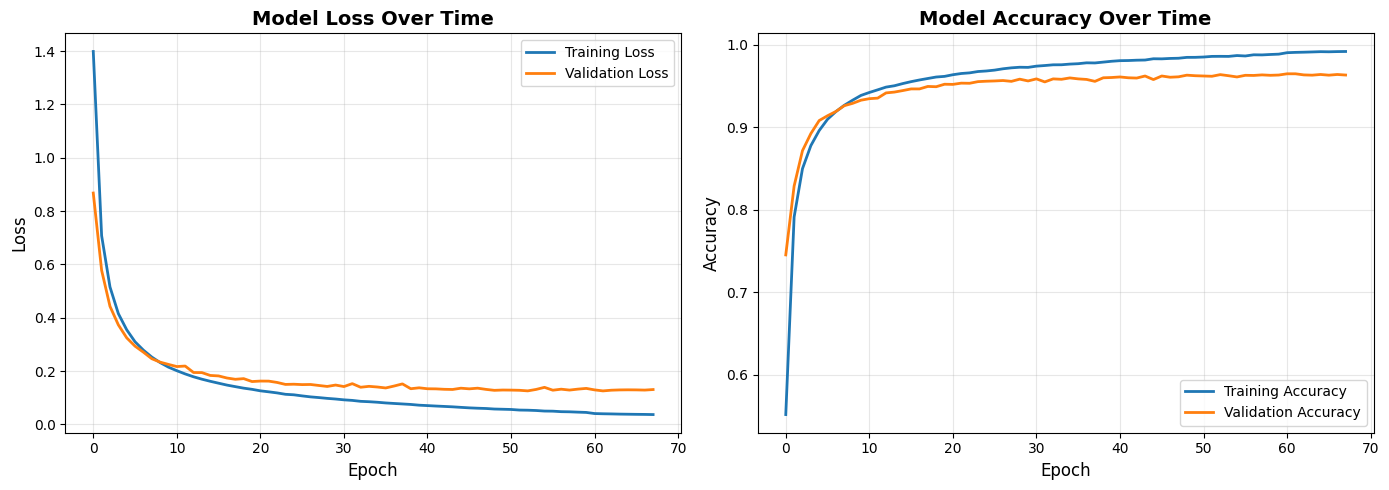

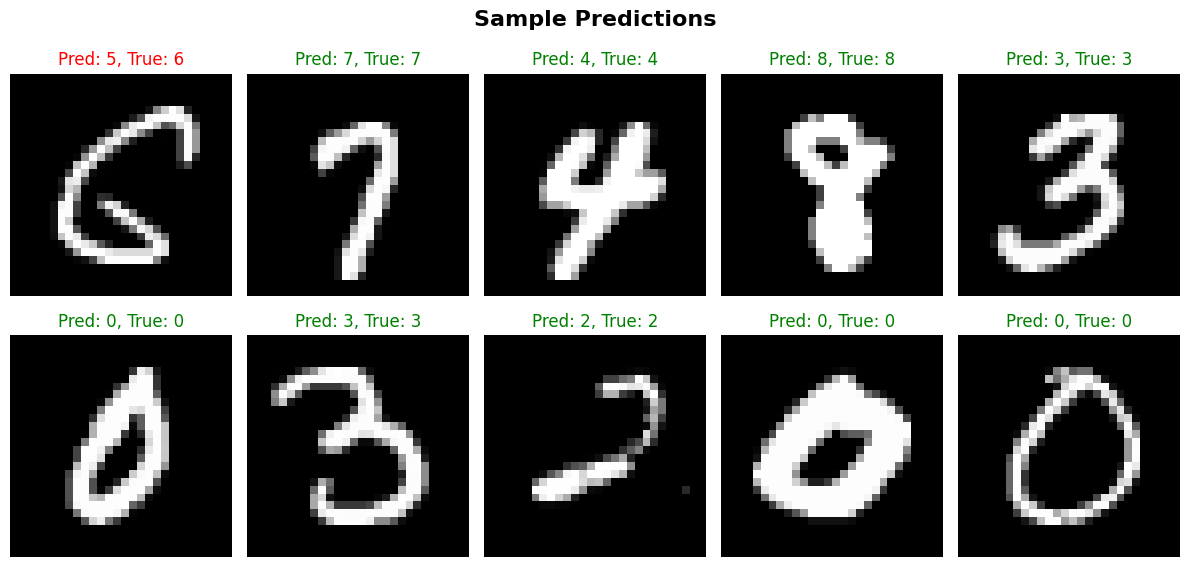


Training complete!
Final test accuracy: 96.34%


In [13]:


print("\n" + "="*70)
print("Evaluating on test set...")
test_probs, _ = model.forward(X_test)
test_preds = np.argmax(test_probs, axis=1)
test_acc = compute_accuracy(test_preds, y_test)
test_loss = compute_loss(test_probs, y_test_oh)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")



fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot loss
ax1.plot(history['train_loss'], label='Training Loss', linewidth=2)
ax1.plot(history['val_loss'], label='Validation Loss', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Model Loss Over Time', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Plot accuracy
ax2.plot(history['train_acc'], label='Training Accuracy', linewidth=2)
ax2.plot(history['val_acc'], label='Validation Accuracy', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title('Model Accuracy Over Time', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



fig, axes = plt.subplots(2, 5, figsize=(12, 6))
axes = axes.ravel()

for i in range(10):
    idx = np.random.randint(0, len(X_test))
    sample = X_test[idx:idx+1]
    pred = model.predict(sample)[0]
    true = y_test[idx]
    
    axes[i].imshow(X_test[idx], cmap='gray')
    axes[i].set_title(f'Pred: {pred}, True: {true}', 
                     color='green' if pred == true else 'red')
    axes[i].axis('off')

plt.suptitle('Sample Predictions', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("Training complete!")
print(f"Final test accuracy: {test_acc:.2%}")

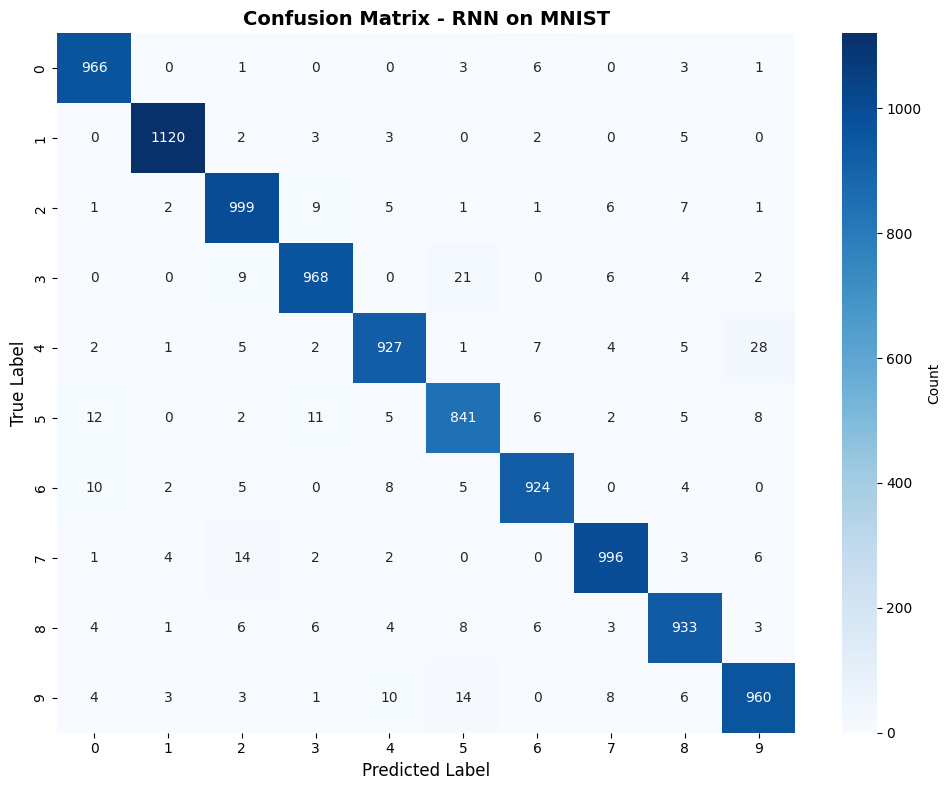


Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.96      0.97      0.96      1032
           3       0.97      0.96      0.96      1010
           4       0.96      0.94      0.95       982
           5       0.94      0.94      0.94       892
           6       0.97      0.96      0.97       958
           7       0.97      0.97      0.97      1028
           8       0.96      0.96      0.96       974
           9       0.95      0.95      0.95      1009

    accuracy                           0.96     10000
   macro avg       0.96      0.96      0.96     10000
weighted avg       0.96      0.96      0.96     10000


Per-Class Accuracy:
Digit 0: 0.9857 (966/980)
Digit 1: 0.9868 (1120/1135)
Digit 2: 0.9680 (999/1032)
Digit 3: 0.9584 (968/1010)
Digit 4: 0.9440 (927/982)
Digit 5: 0.9428 (841/892)
Digit 6: 0.9645 (924/958)
Digit 7: 0

In [15]:
## Confusion Matrix Visualization

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Generate predictions for test set
test_preds = model.predict(X_test)

# Create confusion matrix
cm = confusion_matrix(y_test, test_preds)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=range(10), yticklabels=range(10),
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix - RNN on MNIST', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print detailed classification report
print("\n" + "="*70)
print("Classification Report:")
print("="*70)
print(classification_report(y_test, test_preds, 
                          target_names=[str(i) for i in range(10)]))

# this is each class accuracy
print("\n" + "="*70)
print("Per-Class Accuracy:")
print("="*70)
for i in range(10):
    class_acc = cm[i, i] / cm[i, :].sum()
    print(f"Digit {i}: {class_acc:.4f} ({cm[i, i]}/{cm[i, :].sum()})")

#the pairs the model confused a lot
print("\n" + "="*70)
print("Most Confused Digit Pairs:")
print("="*70)
confused_pairs = []
for i in range(10):
    for j in range(10):
        if i != j and cm[i, j] > 0:
            confused_pairs.append((i, j, cm[i, j]))

confused_pairs.sort(key=lambda x: x[2], reverse=True)
for true_label, pred_label, count in confused_pairs[:10]:
    print(f"True: {true_label} → Predicted: {pred_label} | Count: {count}")